In [1]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os

print(os.listdir("/content/drive/MyDrive"))
print(os.listdir("/content/drive/MyDrive/mtech"))



['Colab Notebooks', 'mtech']
['Test-20260213T111402Z-1-001.zip', 'Validation-20260213T111425Z-1-001.zip', 'Training-20260213T113205Z-1-001.zip']


In [3]:
import zipfile

base_path = "/content/drive/MyDrive/mtech"
extract_path = "/content/hcc_dataset"

os.makedirs(extract_path, exist_ok=True)

for file in os.listdir(base_path):
    if file.endswith(".zip"):
        print("Extracting:", file)
        with zipfile.ZipFile(os.path.join(base_path, file), 'r') as zip_ref:
            zip_ref.extractall(extract_path)

print("Extraction complete")


Extracting: Test-20260213T111402Z-1-001.zip
Extracting: Validation-20260213T111425Z-1-001.zip
Extracting: Training-20260213T113205Z-1-001.zip
Extraction complete


In [4]:
print(os.listdir("/content/hcc_dataset"))


['Test', 'Training', 'Validation']


In [5]:
!pip install timm


In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

import timm
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score


In [7]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model_backbone = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14')
model_backbone = model_backbone.to(device)


Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


In [8]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [9]:
train_path = "/content/hcc_dataset/Training"
val_path = "/content/hcc_dataset/Validation"
test_path = "/content/hcc_dataset/Test"

train_dataset = datasets.ImageFolder(train_path, transform=transform)
val_dataset = datasets.ImageFolder(val_path, transform=transform)
test_dataset = datasets.ImageFolder(test_path, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))


Train: 2549
Validation: 280
Test: 280


In [10]:
class DinoFineTune(nn.Module):
    def __init__(self, backbone, num_classes=4):
        super().__init__()
        self.backbone = backbone
        self.classifier = nn.Linear(384, num_classes)

    def forward(self, x):
        features = self.backbone(x)
        return self.classifier(features)


In [11]:
model_dino = DinoFineTune(model_backbone).to(device)


In [12]:
optimizer = torch.optim.Adam([
    {"params": model_dino.backbone.parameters(), "lr": 1e-5},
    {"params": model_dino.classifier.parameters(), "lr": 1e-3}
])

criterion = nn.CrossEntropyLoss()


In [13]:
epochs = 6

for epoch in range(epochs):
    model_dino.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model_dino(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_acc = 100 * correct / total
    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Loss: {running_loss:.4f} "
          f"Train Acc: {train_acc:.2f}%")


Epoch [1/6] Loss: 39.9492 Train Acc: 79.29%
Epoch [2/6] Loss: 11.1320 Train Acc: 94.23%
Epoch [3/6] Loss: 3.9338 Train Acc: 98.39%
Epoch [4/6] Loss: 3.9878 Train Acc: 98.08%
Epoch [5/6] Loss: 3.0890 Train Acc: 98.71%
Epoch [6/6] Loss: 5.9373 Train Acc: 97.33%


In [14]:
model_dino.eval()
correct = 0
total = 0

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model_dino(images)
        probs = F.softmax(outputs, dim=1)
        _, predicted = torch.max(probs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print("DINO Test Accuracy:", 100 * correct / total)


DINO Test Accuracy: 90.71428571428571


In [15]:
auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')
print("DINO ROC-AUC:", auc)


DINO ROC-AUC: 0.98675


In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset, ConcatDataset
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, confusion_matrix


In [17]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [18]:
train_path = "/content/hcc_dataset/Training"
val_path = "/content/hcc_dataset/Validation"

train_dataset = datasets.ImageFolder(train_path, transform=transform)
val_dataset = datasets.ImageFolder(val_path, transform=transform)

full_dataset = ConcatDataset([train_dataset, val_dataset])


In [19]:
all_labels = []

for _, label in full_dataset:
    all_labels.append(label)

all_labels = np.array(all_labels)


In [20]:
class DinoFineTune(nn.Module):
    def __init__(self, backbone, num_classes=4):
        super().__init__()
        self.backbone = backbone
        self.classifier = nn.Linear(384, num_classes)

    def forward(self, x):
        features = self.backbone(x)
        return self.classifier(features)


In [21]:
device = "cuda" if torch.cuda.is_available() else "cpu"

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

fold_accuracies = []
fold_aucs = []
fold_conf_matrices = []


In [22]:
for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(all_labels)), all_labels)):
    print(f"\n===== Fold {fold+1} =====")

    train_subset = Subset(full_dataset, train_idx)
    val_subset = Subset(full_dataset, val_idx)

    train_loader = DataLoader(train_subset, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_subset, batch_size=32, shuffle=False)

    # Reload fresh DINO each fold
    backbone = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14')
    backbone = backbone.to(device)

    model = DinoFineTune(backbone).to(device)

    optimizer = torch.optim.Adam([
        {"params": model.backbone.parameters(), "lr": 1e-5},
        {"params": model.classifier.parameters(), "lr": 1e-3}
    ])

    criterion = nn.CrossEntropyLoss()

    # Train 8 epochs (sufficient)
    epochs = 8
    for epoch in range(epochs):
        model.train()
        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

    # Validation evaluation
    model.eval()
    correct = 0
    total = 0

    all_preds = []
    all_fold_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            probs = F.softmax(outputs, dim=1)
            _, predicted = torch.max(probs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_fold_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    acc = 100 * correct / total
    fold_accuracies.append(acc)

    auc = roc_auc_score(all_fold_labels, all_probs, multi_class='ovr')
    fold_aucs.append(auc)

    cm = confusion_matrix(all_fold_labels, all_preds)
    fold_conf_matrices.append(cm)

    print(f"Fold Accuracy: {acc:.2f}%")
    print(f"Fold ROC-AUC: {auc:.4f}")



===== Fold 1 =====


Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


Fold Accuracy: 96.92%
Fold ROC-AUC: 0.9996

===== Fold 2 =====


Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


Fold Accuracy: 96.18%
Fold ROC-AUC: 0.9984

===== Fold 3 =====


Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


Fold Accuracy: 96.18%
Fold ROC-AUC: 0.9956


In [23]:
fold_accuracies = np.array(fold_accuracies)
fold_aucs = np.array(fold_aucs)

print("\n===== 3-Fold CV Results (DINO) =====")
print(f"Accuracy: {fold_accuracies.mean():.2f}% ± {fold_accuracies.std():.2f}")
print(f"ROC-AUC: {fold_aucs.mean():.4f} ± {fold_aucs.std():.4f}")



===== 3-Fold CV Results (DINO) =====
Accuracy: 96.43% ± 0.35
ROC-AUC: 0.9979 ± 0.0017


In [24]:
import torch
import torch.nn.functional as F
import numpy as np

model_dino.eval()

dino_preds = []
dino_labels = []
dino_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model_dino(images)
        probs = F.softmax(outputs, dim=1)
        _, predicted = torch.max(probs, 1)

        dino_preds.extend(predicted.cpu().numpy())
        dino_labels.extend(labels.cpu().numpy())
        dino_probs.extend(probs.cpu().numpy())

dino_preds = np.array(dino_preds)
dino_labels = np.array(dino_labels)
dino_probs = np.array(dino_probs)

print("Predictions saved.")


Predictions saved.


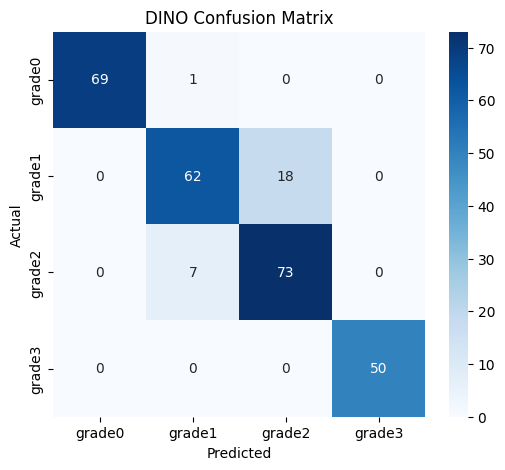

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

class_names = ["grade0", "grade1", "grade2", "grade3"]

cm = confusion_matrix(dino_labels, dino_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title("DINO Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


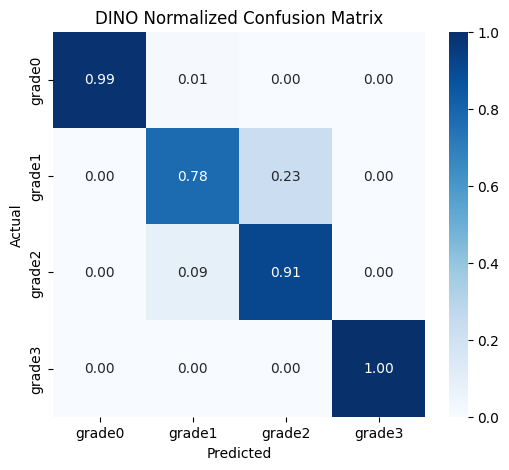

In [26]:
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(6,5))
sns.heatmap(cm_norm,
            annot=True,
            fmt='.2f',
            cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title("DINO Normalized Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [27]:
import torch
import torch.nn.functional as F
import numpy as np

model_dino.eval()

dino_preds = []
dino_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model_dino(images)
        _, predicted = torch.max(outputs, 1)

        dino_preds.extend(predicted.cpu().numpy())
        dino_labels.extend(labels.cpu().numpy())

dino_preds = np.array(dino_preds)
dino_labels = np.array(dino_labels)

print("Predictions saved.")


Predictions saved.


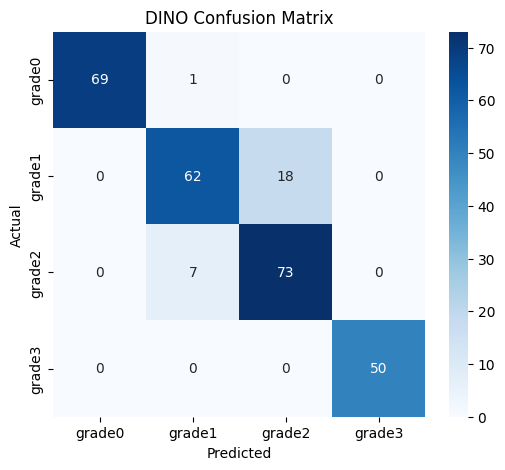

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

class_names = ["grade0", "grade1", "grade2", "grade3"]

cm = confusion_matrix(dino_labels, dino_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title("DINO Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


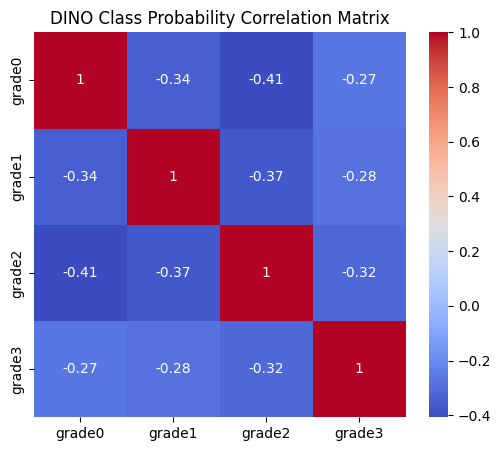

In [29]:
corr_matrix = np.corrcoef(dino_probs.T)

plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title("DINO Class Probability Correlation Matrix")
plt.show()


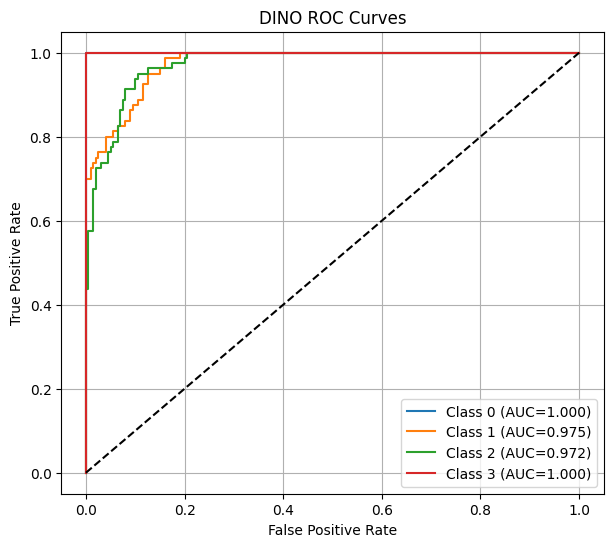

In [30]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

n_classes = 4
dino_labels_bin = label_binarize(dino_labels, classes=[0,1,2,3])

plt.figure(figsize=(7,6))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(dino_labels_bin[:, i], dino_probs[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.3f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("DINO ROC Curves")
plt.legend()
plt.grid()
plt.show()


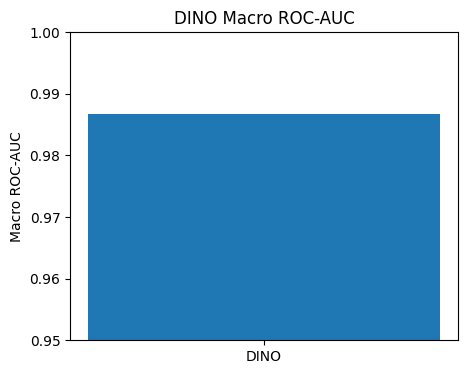

DINO Macro ROC-AUC: 0.98675


In [31]:
from sklearn.metrics import roc_auc_score

macro_auc = roc_auc_score(dino_labels, dino_probs, multi_class='ovr')

plt.figure(figsize=(5,4))
plt.bar(["DINO"], [macro_auc])
plt.ylabel("Macro ROC-AUC")
plt.ylim(0.95, 1.0)
plt.title("DINO Macro ROC-AUC")
plt.show()

print("DINO Macro ROC-AUC:", macro_auc)


In [32]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report


In [33]:
accuracy = accuracy_score(dino_labels, dino_preds)

precision = precision_score(dino_labels, dino_preds, average='weighted')
recall = recall_score(dino_labels, dino_preds, average='weighted')
f1 = f1_score(dino_labels, dino_preds, average='weighted')

print("Overall Metrics:")
print("Accuracy:", accuracy)
print("Precision (Weighted):", precision)
print("Recall (Weighted):", recall)
print("F1-Score (Weighted):", f1)


Overall Metrics:
Accuracy: 0.9071428571428571
Precision (Weighted): 0.9108320251177394
Recall (Weighted): 0.9071428571428571
F1-Score (Weighted): 0.906906534922438


In [34]:
precision_macro = precision_score(dino_labels, dino_preds, average='macro')
recall_macro = recall_score(dino_labels, dino_preds, average='macro')
f1_macro = f1_score(dino_labels, dino_preds, average='macro')

print("\nMacro Average Metrics:")
print("Precision (Macro):", precision_macro)
print("Recall (Macro):", recall_macro)
print("F1-Score (Macro):", f1_macro)



Macro Average Metrics:
Precision (Macro): 0.921978021978022
Recall (Macro): 0.9183035714285714
F1-Score (Macro): 0.9183183979132483


In [35]:
class_names = ["grade0", "grade1", "grade2", "grade3"]

print("\nClassification Report:\n")
print(classification_report(dino_labels, dino_preds, target_names=class_names))



Classification Report:

              precision    recall  f1-score   support

      grade0       1.00      0.99      0.99        70
      grade1       0.89      0.78      0.83        80
      grade2       0.80      0.91      0.85        80
      grade3       1.00      1.00      1.00        50

    accuracy                           0.91       280
   macro avg       0.92      0.92      0.92       280
weighted avg       0.91      0.91      0.91       280

